# Chapter 11 — Unsupervised Learning

**Course 888102 — International College of Digital Innovation, Chiang Mai University**

Chapter 9 introduced unsupervised learning briefly. **This notebook is the complete chapter** — every definition, table, and worked example is here, plus runnable code and step-by-step explanations, so you can follow the whole chapter from the notebook alone; the slides are a condensed version of the same material, useful for review. It goes deeper into four main tasks:

- **Dimensionality reduction** and **anomaly detection** (new this chapter)
- **Clustering** — K-means (step by step) and **hierarchical clustering** (a full worked example)
- **Association rules** — formal terminology (antecedent/consequent) and the support/confidence/lift measures

As always, everything is built from scratch with numpy/pandas so you can see exactly what each algorithm
computes.

### 🆕 Continuing from Chapters 9-10

No prior coding background is assumed, same as Chapters 9 and 10 — see Chapter 9's "New to Python? Start
here" cell for the basics (cells, variables, running code) if you haven't seen it yet. Constructs already
explained there and in Chapter 10 (DataFrames, functions, `.apply()`, boolean arrays/masks, loops,
dictionaries, broadcasting, `np.polyfit`-style helpers) are used again here without re-explaining; the
**🐍 Python basics** cells below cover only what's new to this chapter.

### 🎯 Learning objectives

By the end of this chapter you should be able to:

1. **Name the four unsupervised tasks** — clustering, association rule mining, dimensionality reduction, and
   anomaly detection — and say which job a new dataset/question belongs to.
2. **Run K-means and hierarchical clustering by hand** — build a proximity matrix, merge the two closest
   clusters step by step, read a dendrogram, and cut it at a chosen threshold to get final clusters.
3. **Compute and interpret support, confidence, and lift** for an association rule, and explain why lift —
   not confidence — is the number that tells you whether a pattern is a real association or just two popular
   items.

Along the way you will also see why a highly-correlated feature can be dropped with little information loss
(dimensionality reduction) and why an isolated point stands out as an anomaly (anomaly detection).

### 🗺️ How this notebook is organized

The material is grouped into three parts. Here is where each one lives in this notebook:

| Part | What it asks | Notebook sections |
|---|---|---|
| **1 — Four unsupervised tasks** | What are the four jobs, and what do dimensionality reduction and anomaly detection look like? | §1, §2, §3 |
| **2 — Clustering** | How do K-means and hierarchical clustering actually group points? | §4 |
| **3 — Association rules** | How do you measure whether "if X then Y" is a real pattern? | §5 |

§6 is the summary and glossary. §7 is the graded homework.

**How to work through it:** read each section's explanation, run the code cell under it, then read the
"Interpretation" note that follows — that note tells you what the output you just produced actually means.
The **✏️ Try it** boxes are small challenges with answers given right after; they are not graded, but doing
them yourself first is the fastest way to find out whether you really understood the section. The graded
work is §7.

In [1]:
# Import the libraries (run this cell first — everything below depends on it!)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(888102)  # fixed seed so every student gets identical numbers

## 1. Unsupervised learning tasks

Unsupervised learning identifies patterns in data that is neither classified nor labeled -- the machine
sorts information by similarities and differences, with no predefined categories. It covers four main tasks:

| Task | Goal |
|---|---|
| **Clustering** | Group similar data points together |
| **Association rule** | Find "if X then Y" relationships between items |
| **Dimensionality reduction** | Reduce the number of features, keeping the important information |
| **Anomaly detection** | Flag data points that deviate from the norm |

## 2. Dimensionality reduction

Real datasets often have redundant or correlated features. Dimensionality reduction finds a smaller set of
features that still captures most of the important information -- e.g. collapsing a 3-D feature space into
2-D when one dimension turns out to be mostly redundant with another.

**🐍 Python basics — a 3D subplot and correlation**

- `fig.add_subplot(1, 2, 1, projection="3d")` creates a drawing area that can plot in **three** dimensions
  (x, y, and z) instead of the usual two — `projection="3d"` is what switches it on. `ax1.scatter(x, y, z,
  ...)` then needs all three coordinates per point instead of the usual two.
- `np.corrcoef(a, b)` measures **correlation**: how strongly two variables move together, from -1 (perfectly
  opposite) through 0 (unrelated) to +1 (perfectly together). It returns a small 2x2 table, and
  `[0, 1]` picks out the one number we actually want (the correlation between `a` and `b`, not each
  variable's correlation with itself).

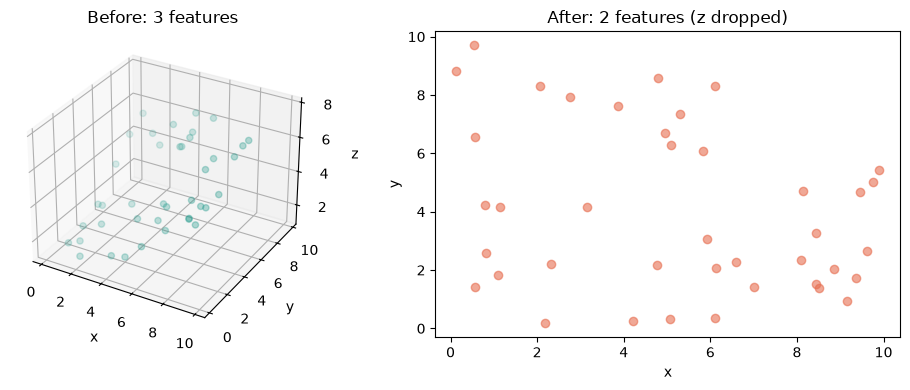

Correlation between z and (x+y)/2: 0.985 -- z carries almost no new information


In [2]:
# Simulate 3 features where one (feature_z) is almost entirely explained by the other two
n_points = 40
feature_x = rng.uniform(0, 10, n_points)
feature_y = rng.uniform(0, 10, n_points)
feature_z = 0.5 * feature_x + 0.5 * feature_y + rng.normal(0, 0.3, n_points)  # redundant: mostly x+y

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(feature_x, feature_y, feature_z, alpha=0.6, color="#2A9D8F")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("Before: 3 features")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(feature_x, feature_y, alpha=0.6, color="#E76F51")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("After: 2 features (z dropped)")

plt.tight_layout()
plt.show()

correlation = np.corrcoef(0.5 * feature_x + 0.5 * feature_y, feature_z)[0, 1]
print(f"Correlation between z and (x+y)/2: {correlation:.3f} -- z carries almost no new information")

**Interpretation:** `feature_z` is almost perfectly predictable from `x` and `y`, so dropping it loses
barely any information while cutting the dataset from 3 dimensions to 2 -- exactly the idea in the
cylinder diagram, where a 3-D feature space collapses into a simpler 2-D one.

### 2.1 Doing it properly — principal component analysis

Spotting that `feature_z` duplicates `x` and `y` worked because there were only three columns. With 200
columns you cannot eyeball a correlation matrix, and **principal component analysis** automates the job.

PCA finds new axes — **principal components** — along which the data actually varies. The first component
points along the direction of greatest spread, the second along the greatest remaining spread perpendicular to
it, and so on. Keep the first few and you keep most of the information.

**PCA in four steps.** Do not be put off by the vocabulary — the arithmetic is addition, multiplication and one
square root, and the example below carries a four-row dataset all the way through.

**Step 1 — put every column on the same footing.** Subtract each column's average, and divide by how much that
column typically varies:

$$z = \frac{x - \bar{x}}{s}$$

This matters because PCA hunts for the columns that *vary the most*, and a column measured in millimetres would win
against the identical column measured in metres purely by having bigger numbers.

**Step 2 — measure which columns move together.** Build the **covariance matrix** $\mathbf{C}$. For two columns
$X$ and $Y$ the entry linking them is

$$\text{cov}(X, Y) = \frac{1}{n-1}\sum_{i=1}^{n}\left(X_i - \bar{X}\right)\left(Y_i - \bar{Y}\right)$$

Read it exactly like the regression slope in Chapter 10: *when this row is above average on $X$, is it also above
average on $Y$?* A large positive value means the two columns are telling you much the same thing — which is the
redundancy PCA is looking for.

**Step 3 — find the new axes.** These are the **eigenvectors** of $\mathbf{C}$, and each comes with a number
$\lambda$ (*lambda*), its **eigenvalue**, satisfying

$$\mathbf{C}\,\mathbf{v} = \lambda \mathbf{v}$$

In words: an eigenvector is a direction that the matrix stretches without turning, and $\lambda$ is how much it
stretches. For a covariance matrix that stretch **is** the amount of variation along that direction — so the
eigenvector with the biggest $\lambda$ is the direction the data spreads out most. That is the first principal
component. Sort by $\lambda$, biggest first, and you have ranked your new axes from most to least informative.

**Step 4 — decide how many to keep**, using each component's share of the total:

$$\text{explained variance ratio} = \frac{\lambda_m}{\lambda_1 + \lambda_2 + \dots + \lambda_p}$$

> **Worked example — four shops, two columns.**
>
> | Shop | Floor area $X$ | Staff $Y$ |
> |---|---|---|
> | 1 | 2 | 3 |
> | 2 | 4 | 7 |
> | 3 | 6 | 5 |
> | 4 | 8 | 9 |
>
> **Averages:** $\bar{X} = (2+4+6+8)/4 = 5$, $\bar{Y} = (3+7+5+9)/4 = 6$.
>
> **Deviations from those averages:**
>
> | Shop | $X - \bar{X}$ | $Y - \bar{Y}$ | product | $(X-\bar{X})^2$ | $(Y-\bar{Y})^2$ |
> |---|---|---|---|---|---|
> | 1 | $-3$ | $-3$ | $9$ | $9$ | $9$ |
> | 2 | $-1$ | $+1$ | $-1$ | $1$ | $1$ |
> | 3 | $+1$ | $-1$ | $-1$ | $1$ | $1$ |
> | 4 | $+3$ | $+3$ | $9$ | $9$ | $9$ |
> | **total** | | | $\mathbf{16}$ | $\mathbf{20}$ | $\mathbf{20}$ |
>
> **The covariance matrix** (divide each total by $n - 1 = 3$):
>
> $$\mathbf{C} = \begin{bmatrix} 20/3 & 16/3 \\ 16/3 & 20/3 \end{bmatrix} = \begin{bmatrix} 6.67 & 5.33 \\ 5.33 & 6.67 \end{bmatrix}$$
>
> **The eigenvalues.** For a matrix shaped like $\begin{bmatrix} a & b \\ b & a \end{bmatrix}$ there is a shortcut:
> the eigenvalues are simply $a + b$ and $a - b$.
>
> $\lambda_1 = 6.67 + 5.33 = \mathbf{12.0}$, in the direction $(1, 1)$ — *"area and staff rise together"*.
> $\lambda_2 = 6.67 - 5.33 = \mathbf{1.33}$, in the direction $(1, -1)$ — *"one is high while the other is low"*.
>
> **The shares.** Total $= 12.0 + 1.33 = 13.33$.
>
> $\text{EVR}_1 = 12.0 / 13.33 = \mathbf{90\%}$ and $\text{EVR}_2 = 1.33 / 13.33 = \mathbf{10\%}$.
>
> **What this tells you.** 90% of everything these two columns say is captured by one combined number, "how big is
> this shop". You could throw away the second column, keep a single score per shop, and lose only a tenth of the
> information. That is dimensionality reduction, done properly, on four rows you can check by hand.

The usual rule is to keep enough components to reach 90–95% cumulative — and if two components get you there, a
dataset with 200 columns can be drawn on ordinary paper.

In [3]:
# Build the same three features, then let PCA discover the redundancy on its own.
rng_pca = np.random.default_rng(888102)

n = 300
feature_x = rng_pca.normal(0, 1, n)
feature_y = rng_pca.normal(0, 1, n)
feature_z = (feature_x + feature_y) / 2 + rng_pca.normal(0, 0.12, n)   # nearly redundant

data = np.column_stack([feature_x, feature_y, feature_z])
centered = data - data.mean(axis=0)

# PCA via the singular value decomposition.
U, singular_values, Vt = np.linalg.svd(centered, full_matrices=False)
variance_explained = singular_values ** 2 / (singular_values ** 2).sum()

print("Variance explained by each principal component:")
cumulative = 0.0
for i, share in enumerate(variance_explained, start=1):
    cumulative += share
    print(f"  PC{i}: {share:6.1%}   (cumulative {cumulative:6.1%})")

print("\nWhat each component is built from (loadings):")
loadings = pd.DataFrame(Vt.T, index=["feature_x", "feature_y", "feature_z"],
                        columns=[f"PC{i+1}" for i in range(3)]).round(3)
print(loadings.to_string())

Variance explained by each principal component:
  PC1:  62.5%   (cumulative  62.5%)
  PC2:  37.1%   (cumulative  99.6%)
  PC3:   0.4%   (cumulative 100.0%)

What each component is built from (loadings):
             PC1    PC2    PC3
feature_x -0.549 -0.730  0.407
feature_y -0.609  0.683  0.404
feature_z -0.573 -0.026 -0.819


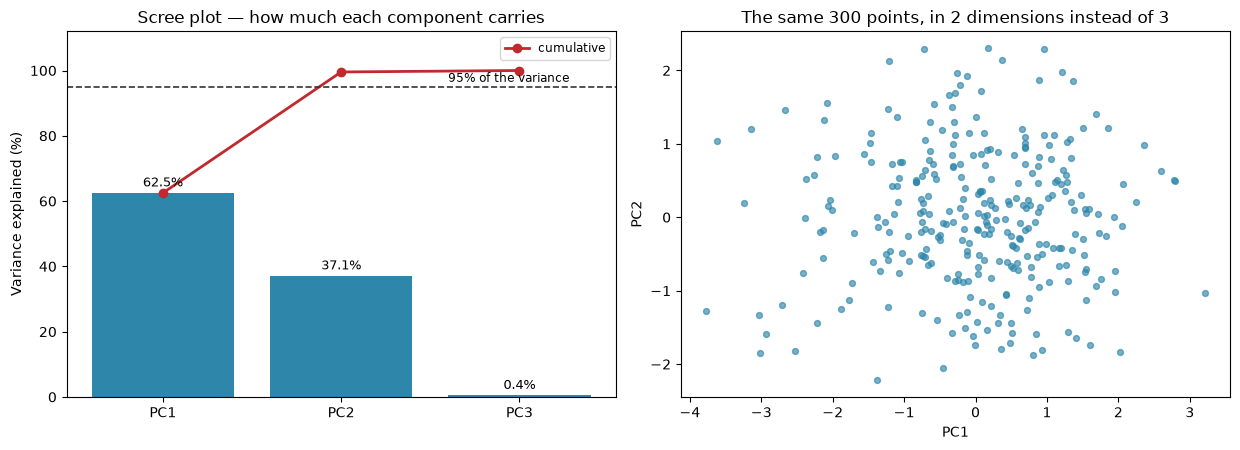

Kept 2 of 3 components -> 99.6% of the variance retained.
Average reconstruction error per value: 0.0589
(For comparison, the features themselves have standard deviations [0.95, 0.97, 0.69].)


In [4]:
fig, (ax_scree, ax_proj) = plt.subplots(1, 2, figsize=(12.5, 4.6))

components = [f"PC{i+1}" for i in range(3)]
ax_scree.bar(components, variance_explained * 100, color="#2E86AB")
ax_scree.plot(components, np.cumsum(variance_explained) * 100, marker="o",
              color="#C1292E", linewidth=2, label="cumulative")
ax_scree.axhline(95, color="#333", linestyle="--", linewidth=1.2)
ax_scree.text(1.6, 96.5, "95% of the variance", fontsize=8.5)
for comp, share in zip(components, variance_explained):
    ax_scree.text(comp, share * 100 + 2, f"{share:.1%}", ha="center", fontsize=9)
ax_scree.set_ylabel("Variance explained (%)")
ax_scree.set_title("Scree plot — how much each component carries")
ax_scree.set_ylim(0, 112)
ax_scree.legend(fontsize=8.5)

# Project the 3-D data down onto its first two components.
projected = centered @ Vt[:2].T
ax_proj.scatter(projected[:, 0], projected[:, 1], s=18, alpha=0.65, color="#2E86AB")
ax_proj.set_xlabel("PC1")
ax_proj.set_ylabel("PC2")
ax_proj.set_title("The same 300 points, in 2 dimensions instead of 3")

plt.tight_layout()
plt.show()

# How much did we actually lose by dropping PC3?
reconstructed = projected @ Vt[:2] + data.mean(axis=0)
reconstruction_error = np.sqrt(((data - reconstructed) ** 2).mean())
print(f"Kept 2 of 3 components -> {variance_explained[:2].sum():.1%} of the variance retained.")
print(f"Average reconstruction error per value: {reconstruction_error:.4f}")
print(f"(For comparison, the features themselves have standard deviations "
      f"{data.std(axis=0).round(2).tolist()}.)")

**Interpretation:** two components capture almost all the variance, and the third carries almost none — which
is the mathematical restatement of "z is nearly redundant." Reconstructing the original three columns from
just two components loses very little, and the reconstruction error confirms it numerically.

**Two things PCA is not:**

- **It is not feature selection.** PCA does not tell you to *drop* `feature_z`; it replaces all three columns
  with combinations of them. If you need to keep original, meaningful columns — because a stakeholder must
  understand the model — PCA is the wrong tool.
- **It is not scale-invariant.** PCA maximizes variance, and a column measured in baht has vastly more
  variance than one measured in years. **Standardize before running PCA**, or the component with the largest
  units will dominate every result.

⚠️ **The cost is interpretability.** "PC1 increased by 2" means nothing to anyone. Read the loadings table to
see which original features dominate each component and give them names — but treat those names as
interpretation, not fact. Chapter 4's data-reduction section makes the same point.

## 3. Anomaly detection

Anomalies (also called outliers, noise, or exceptions) are data patterns that deviate from the standard
behavior of the rest of the data. Anomaly detection flags points that don't belong to any normal cluster.

**🐍 Python basics — `np.fill_diagonal` and the `~` (not) operator**

- `distances = np.linalg.norm(all_points[:, None, :] - all_points[None, :, :], axis=2)` is the same
  broadcasting distance trick from Chapter 9's k-means, but here every point is compared to *every other
  point in the same dataset* — including itself, which always gives a distance of exactly 0.
  `np.fill_diagonal(distances, np.inf)` overwrites just the diagonal (each point's distance to itself) with
  infinity, so that "distance to itself" never gets mistaken for the nearest neighbor.
- `~is_anomaly` is the **not** operator applied to a boolean array — it flips every `True` to `False` and
  vice versa. `all_points[~is_anomaly, 0]` therefore selects the x-coordinates of every point that is **not**
  flagged as an anomaly (the normal ones), while `all_points[is_anomaly, 0]` selects the flagged ones.

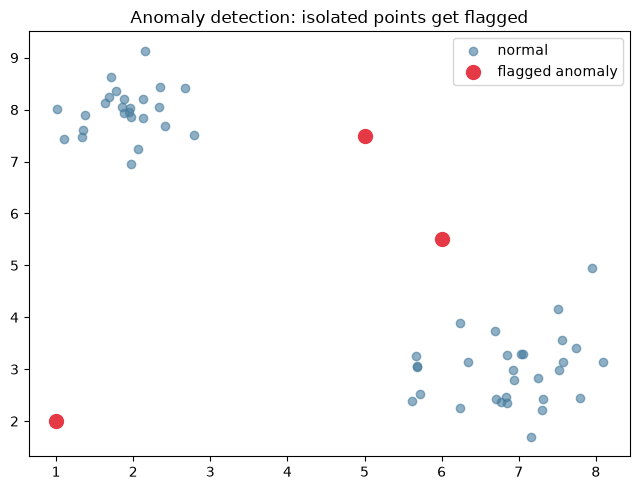

Flagged 3 anomalies out of 58 points.


In [5]:
# Two normal clusters (N1, N2), plus 3 outliers (O1, O2, O3) -- reproducing the figure
normal_1 = rng.normal(loc=(2, 8), scale=0.5, size=(25, 2))
normal_2 = rng.normal(loc=(7, 3), scale=0.7, size=(30, 2))
outliers = np.array([[5.0, 7.5], [6.0, 5.5], [1.0, 2.0]])

all_points = np.vstack([normal_1, normal_2, outliers])
labels = ["N1"] * len(normal_1) + ["N2"] * len(normal_2) + ["O1", "O2", "O3"]

# A simple anomaly rule: flag any point whose nearest neighbor is "too far away"
distances = np.linalg.norm(all_points[:, None, :] - all_points[None, :, :], axis=2)
np.fill_diagonal(distances, np.inf)
nearest_neighbor_dist = distances.min(axis=1)
is_anomaly = nearest_neighbor_dist > 1.0  # threshold: an isolated point has no close neighbors

plt.figure(figsize=(6.5, 5))
plt.scatter(all_points[~is_anomaly, 0], all_points[~is_anomaly, 1], color="#457B9D", label="normal", alpha=0.6)
plt.scatter(all_points[is_anomaly, 0], all_points[is_anomaly, 1], color="#E63946", label="flagged anomaly", s=100)
plt.legend()
plt.title("Anomaly detection: isolated points get flagged")
plt.tight_layout()
plt.show()

print(f"Flagged {is_anomaly.sum()} anomalies out of {len(all_points)} points.")

**Interpretation:** the two dense clouds (N1, N2) are "normal behavior" -- most points there have close
neighbors. The 3 injected outliers sit far from both clouds, so their nearest neighbor is unusually distant,
which is exactly the signal our simple rule uses to flag them.

### 3.1 Four ways to say "this point does not belong"

The nearest-neighbor rule above is one method. It is worth seeing several, because they disagree — and the
disagreement is the point.

| Method | Flags a point when… | Assumes | Good for |
|---|---|---|---|
| **Z-score** | It is more than 3 s.d. from the mean | Roughly bell-shaped data | Simple, one-dimensional cases |
| **IQR** | It falls outside Q1 − 1.5·IQR or Q3 + 1.5·IQR | Nothing about shape | Skewed one-dimensional data |
| **kNN distance** | Its nearest neighbors are unusually far away | Normal points have close company | Clusters of any shape |
| **Local density** | It sits in a much sparser region than its neighbors do | Density varies across the data | Clusters of *different* densities |

**The same four rules, as formulas.**

**Z-score** — how many standard deviations from the average:

$$z_i = \frac{x_i - \bar{x}}{s} \qquad\qquad \text{flag it when } \lvert z_i \rvert > 3$$

**IQR** — how far outside the middle half of the data:

$$\text{IQR} = Q_3 - Q_1 \qquad \text{flag it when } x_i < Q_1 - 1.5\,\text{IQR} \;\text{ or }\; x_i > Q_3 + 1.5\,\text{IQR}$$

$Q_1$ is the value a quarter of the way through the sorted data, $Q_3$ three quarters of the way. The gap between
them, the IQR, is where the middle half of your data lives.

> **Worked example — and a genuine surprise.** Five daily transaction counts: $10, 12, 11, 13, 50$. The $50$ is
> obviously the odd one out. Do both rules agree?
>
> **The z-score rule.**
> Average: $(10+12+11+13+50)/5 = 96/5 = 19.2$.
> Deviations: $-9.2, -7.2, -8.2, -6.2, +30.8$. Squared: $84.6, 51.8, 67.2, 38.4, 948.6$; total $1190.8$.
> Standard deviation: $s = \sqrt{1190.8 / 4} = \sqrt{297.7} = 17.3$.
> Z-score of the 50: $z = (50 - 19.2)/17.3 = \mathbf{1.79}$.
>
> **$1.79$ is nowhere near $3$, so the z-score rule does not flag it.**
>
> **The IQR rule.** Sorted: $10, 11, 12, 13, 50$. Here $Q_1 = 11$ and $Q_3 = 13$, so $\text{IQR} = 2$.
> Upper fence: $13 + 1.5 \times 2 = \mathbf{16}$. Since $50 > 16$, **the IQR rule flags it immediately.**
>
> **What just happened.** The outlier corrupted the very numbers meant to catch it. It dragged the average up from
> about 11.5 to 19.2, and it inflated the standard deviation to 17.3 almost single-handedly — then measured itself
> against that inflated ruler and looked ordinary. Quartiles are positions in a sorted list, so one wild value
> barely moves them. **An outlier can hide from the z-score; it cannot hide from the IQR.**

**kNN distance** — how far away your nearest neighbors are:

$$\text{score}(\mathbf{x}_i) = \frac{1}{k}\sum_{\mathbf{x}_j \,\in\, N_k(\mathbf{x}_i)} d(\mathbf{x}_i, \mathbf{x}_j)$$

A big average distance to your own closest neighbors means nobody is near you. Unlike the first two, this one works
with any number of columns and assumes nothing about the shape of the data.

**Local density (LOF)** — how your crowding compares with your neighbors' crowding:

$$\text{LOF}_k(\mathbf{x}_i) = \frac{\text{how tightly packed my neighbors are}}{\text{how tightly packed I am}}$$

> **Worked example — why the comparison matters.** Imagine two groups: a dense city cluster where neighbors sit
> $0.1$ km apart, and a sparse rural cluster where neighbors sit $5$ km apart.
>
> A city point that has drifted to $1$ km from its neighbors has a kNN distance of $1$ — far *smaller* than any
> normal rural point's $5$. **Plain kNN distance would flag every rural resident and miss the drifting city
> point entirely.**
>
> LOF asks a relative question instead: this point is $1$ km out while its neighbors are $0.1$ km apart, so
> $\text{LOF} \approx 1/0.1 = 10$ — extremely unusual. A normal rural point sits $5$ km out among neighbors who
> are also $5$ km apart, giving $\text{LOF} \approx 5/5 = 1$ — perfectly normal.

Read LOF as a ratio: near $1$ means "as crowded as everyone around me"; much greater than $1$ means "my neighbors
have company and I do not."

In [6]:
rng_anomaly = np.random.default_rng(888102)

# One DENSE cluster and one SPARSE cluster, plus three genuine outliers.
dense = rng_anomaly.normal(loc=(2, 2), scale=0.35, size=(60, 2))
sparse = rng_anomaly.normal(loc=(8, 8), scale=1.40, size=(30, 2))
outliers = np.array([[5.0, 1.0], [1.0, 8.5], [11.5, 2.0]])
cloud = np.vstack([dense, sparse, outliers])
is_outlier = np.r_[np.zeros(90, dtype=bool), np.ones(3, dtype=bool)]

# Pairwise distances, with self-distance removed.
pairwise = np.linalg.norm(cloud[:, None, :] - cloud[None, :, :], axis=2)
np.fill_diagonal(pairwise, np.inf)

K_NEIGHBORS = 5
neighbor_distances = np.sort(pairwise, axis=1)[:, :K_NEIGHBORS]
knn_score = neighbor_distances.mean(axis=1)

# Local density: how does my neighborhood size compare with my neighbors' neighborhood sizes?
neighbor_index = np.argsort(pairwise, axis=1)[:, :K_NEIGHBORS]
local_density_score = knn_score / knn_score[neighbor_index].mean(axis=1)

# Simple one-dimensional rules, applied to the distance from the overall center.
radius = np.linalg.norm(cloud - cloud.mean(axis=0), axis=1)
z_flag = np.abs((radius - radius.mean()) / radius.std()) > 3
q1, q3 = np.percentile(radius, [25, 75])
iqr_flag = (radius < q1 - 1.5 * (q3 - q1)) | (radius > q3 + 1.5 * (q3 - q1))
knn_flag = knn_score > np.percentile(knn_score, 95)
density_flag = local_density_score > 1.8

summary = pd.DataFrame({
    "Flagged in total": [z_flag.sum(), iqr_flag.sum(), knn_flag.sum(), density_flag.sum()],
    "True outliers caught (of 3)": [(z_flag & is_outlier).sum(), (iqr_flag & is_outlier).sum(),
                                    (knn_flag & is_outlier).sum(), (density_flag & is_outlier).sum()],
    "False alarms": [(z_flag & ~is_outlier).sum(), (iqr_flag & ~is_outlier).sum(),
                     (knn_flag & ~is_outlier).sum(), (density_flag & ~is_outlier).sum()],
}, index=["Z-score (3σ)", "IQR", "kNN distance (top 5%)", "Local density"])
summary

,Flagged in total,True outliers caught (of 3),False alarms
Z-score (3σ),0,0,0
IQR,4,1,3
kNN distance (top 5%),5,3,2
Local density,10,3,7


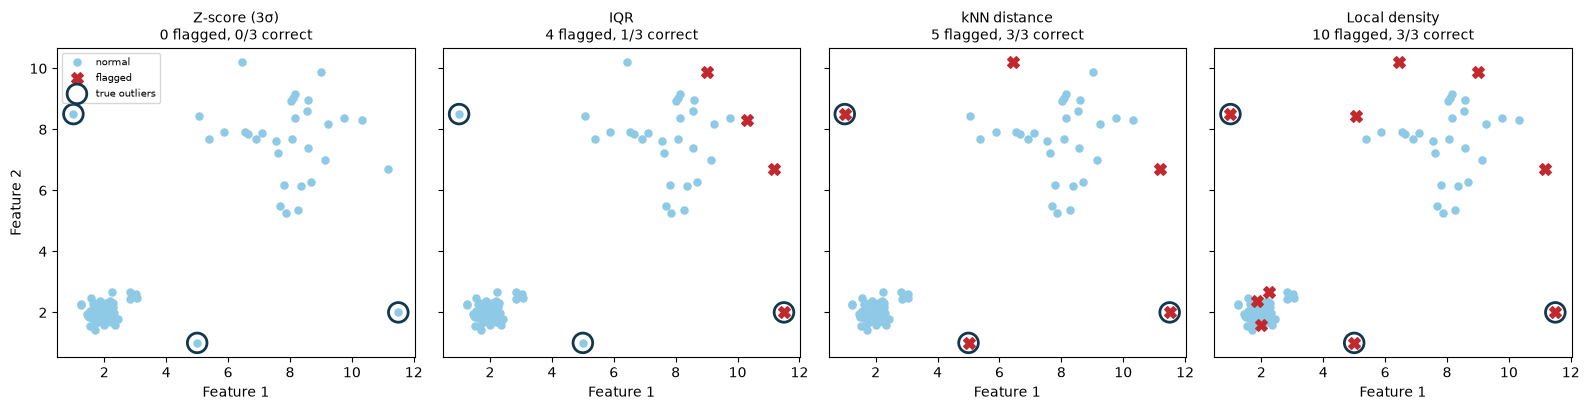

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharex=True, sharey=True)
for ax, (flags, name) in zip(axes, [(z_flag, "Z-score (3σ)"), (iqr_flag, "IQR"),
                                    (knn_flag, "kNN distance"), (density_flag, "Local density")]):
    ax.scatter(cloud[~flags, 0], cloud[~flags, 1], s=26, color="#8ECAE6", label="normal")
    ax.scatter(cloud[flags, 0], cloud[flags, 1], s=70, color="#C1292E", marker="X", label="flagged")
    ax.scatter(outliers[:, 0], outliers[:, 1], s=200, facecolors="none",
               edgecolors="#12384f", linewidth=2, label="true outliers")
    ax.set_title(f"{name}\n{flags.sum()} flagged, {(flags & is_outlier).sum()}/3 correct", fontsize=10)
    ax.set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend(fontsize=7.5, loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** the four methods do not agree, and the reason is structural rather than accidental.

The **z-score** and **IQR** rules were applied to distance-from-center, so they see the data as
one-dimensional and cannot distinguish "far from the middle" from "isolated." A point in the middle of the
sparse cluster is far from center and perfectly normal; the outlier at (5, 1) sits *between* the two clusters
and is not especially far from center at all.

**kNN distance** does much better, because it asks the right question — *is anything near me?* — but it uses
one global threshold. That is a problem when clusters have different densities: a normal point in the sparse
cluster has neighbors farther away than an outlier next to the dense cluster does.

**Local density** fixes exactly that by comparing each point's neighborhood to *its own neighbors'*
neighborhoods, making the test relative rather than absolute. This is the idea behind the Local Outlier Factor
algorithm.

**The lesson that matters more than any of the four:** anomaly detection has no labels, so there is nothing to
validate against. Every method needs a threshold, every threshold is a choice about how many false alarms you
will tolerate, and **the algorithm cannot tell you whether a flagged point is a fraud, a sensor fault, or your
most interesting customer.** That determination is Chapter 6's "identify, explain, then decide," and it is
still a human job.

> ✏️ **Try it:** change `K_NEIGHBORS` from 5 to 2 and then to 20. Which method's results move most, and why
> does the choice of k matter so much for a density-based method?

## 4. Clustering

**In the real world, you already do this every time you shop.** At a mall, t-shirts group in one section, trousers in another; apples, bananas, and mangoes sit together in the produce section — everything is grouped by similarity so shoppers can find things. Clustering is that same idea, done automatically on data that has no pre-made sections.

| Use case | What gets clustered |
|---|---|
| **Document grouping** | Documents cluster by topic, without anyone tagging the topic first |
| **Biology** | Species of plants and animals, classified via image recognition |
| **Search engines** | Similar results grouped together, far from dissimilar ones |
| **Customer segmentation** | Customers grouped by choice and preference, for market research |

### 4.1 Hard vs. soft clustering

- **Hard clustering** (e.g. K-means): each point belongs to exactly one cluster.
- **Soft clustering** (e.g. hierarchical clustering, fuzzy methods): a point can have a degree of membership
  across multiple clusters.

**How to measure "closeness" between two points:**

| Distance metric | Idea |
|---|---|
| Euclidean | Straight-line distance — the everyday sense of "distance" |
| Manhattan | Sum of absolute differences along each axis — city-block distance |
| Maximum | The single largest difference across any one axis |

The proximity matrix built later in this chapter uses absolute difference (Manhattan distance, in 1-D); the
k-means and anomaly-detection code above use Euclidean distance (`np.linalg.norm`).

### 4.2 K-means, step by step

Recall from Chapter 9: (1) choose `k`, (2) pick `k` random centroids, (3) assign every point to its nearest
centroid, (4) recompute centroids, (5) repeat until stable. Let's watch it happen step by step this time.

**The difference comes down to what one number is allowed to be.** Write $u_{ij}$ for *how much point $i$ belongs
to cluster $j$*. Both kinds of clustering insist a point's memberships add up to one whole point; they differ only
in whether partial membership is permitted:

$$\text{hard: } u_{ij} \in \{0, 1\}
\qquad\qquad
\text{soft: } u_{ij} \in [0, 1]
\qquad\qquad
\text{both: } \sum_{j=1}^{k} u_{ij} = 1$$

> **Worked example — one customer, three clusters.**
>
> | | Cluster 1 | Cluster 2 | Cluster 3 | Sum |
> |---|---|---|---|---|
> | **Hard** (k-means) | $1$ | $0$ | $0$ | $1$ ✓ |
> | **Soft** (fuzzy) | $0.6$ | $0.3$ | $0.1$ | $1$ ✓ |
>
> The hard answer says "this customer is a weekday commuter, full stop." The soft answer says "mostly a weekday
> commuter, partly a weekend shopper, with a trace of something else" — and for a customer who genuinely sits
> between two groups, that is the more honest description. The catch is that soft answers are harder to act on:
> you cannot post a leaflet to $0.6$ of a person.

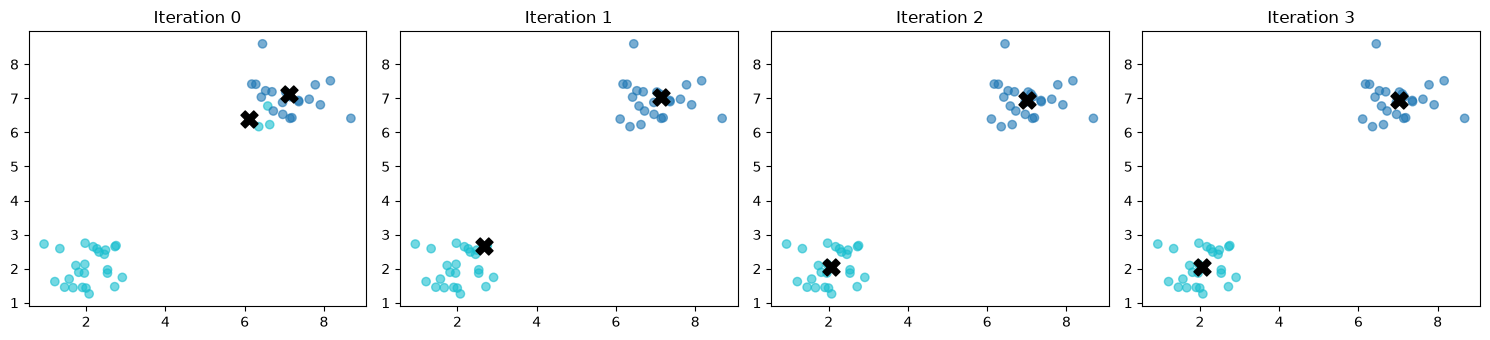

In [8]:
# The same two-blob dataset style as Chapter 9, but this time we snapshot every iteration
group_1 = rng.normal(loc=(2, 2), scale=0.6, size=(25, 2))
group_2 = rng.normal(loc=(7, 7), scale=0.6, size=(25, 2))
points = np.vstack([group_1, group_2])

k = 2
local_rng = np.random.default_rng(888102)
centroids = points[local_rng.choice(len(points), size=k, replace=False)]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
snapshots = [0, 1, 2, 3]

for step in range(4):
    distances = np.linalg.norm(points[:, None, :] - centroids[None, :, :], axis=2)
    assignments = distances.argmin(axis=1)
    axes[step].scatter(points[:, 0], points[:, 1], c=assignments, cmap="tab10", alpha=0.6)
    axes[step].scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=150)
    axes[step].set_title(f"Iteration {step}")
    new_centroids = np.array([points[assignments == c].mean(axis=0) for c in range(k)])
    centroids = new_centroids

plt.tight_layout()
plt.show()

**Interpretation:** even though the centroids started at two random data points (iteration 0), by
iteration 1 or 2 they've already snapped to roughly the true center of each blob, and stay there -- this is
the "no further switching of points between clusters" stopping criterion.

### 4.2 Distance is a choice, not a fact

Every clustering algorithm needs a definition of "close." There are three:

| Metric | Formula | Idea |
|---|---|---|
| **Euclidean** | √Σ(xᵢ − yᵢ)² | Straight-line distance — the everyday sense of "distance" |
| **Manhattan** | Σ\|xᵢ − yᵢ\| | City-block distance — you cannot cut through buildings |
| **Maximum (Chebyshev)** | maxᵢ \|xᵢ − yᵢ\| | The single largest difference on any one axis |

They are not interchangeable, and swapping one for another can change which points count as neighbors.

**The three, written properly.** For two records $\mathbf{x}$ and $\mathbf{y}$ with $p$ columns:

$$d_{\text{Euclidean}} = \sqrt{\sum_{j=1}^{p}\left(x_j - y_j\right)^{2}}
\qquad
d_{\text{Manhattan}} = \sum_{j=1}^{p}\left\lvert x_j - y_j \right\rvert
\qquad
d_{\text{Chebyshev}} = \max_{j}\left\lvert x_j - y_j \right\rvert$$

> **Worked example — the same two points, three answers.** $\mathbf{x} = (1, 2)$ and $\mathbf{y} = (4, 6)$.
> The gaps are $\lvert 1-4 \rvert = 3$ and $\lvert 2-6 \rvert = 4$.
>
> **Euclidean:** $\sqrt{3^2 + 4^2} = \sqrt{25} = \mathbf{5}$ — straight line.
> **Manhattan:** $3 + 4 = \mathbf{7}$ — around the corner.
> **Chebyshev:** $\max(3, 4) = \mathbf{4}$ — only the worst single column counts.
>
> $4$, $5$, $7$. Same two points, three different notions of "how far apart" — and since every clustering
> algorithm in this chapter decides what to merge by comparing distances, that choice can change your answer.

All three are one formula with a dial turned. The **Minkowski distance** of order $r$ is

$$d_r(\mathbf{x}, \mathbf{y}) = \left(\sum_{j=1}^{p}\left\lvert x_j - y_j \right\rvert^{r}\right)^{1/r}$$

Set $r = 1$ and you get Manhattan; $r = 2$ gives Euclidean; and as $r$ grows the largest single gap increasingly
drowns out the rest until, in the limit, only it survives — that is Chebyshev.

Two more that are not Minkowski at all, and that matter for the data types this course meets elsewhere:

$$\text{cosine similarity} = \frac{\mathbf{x} \cdot \mathbf{y}}{\lVert \mathbf{x} \rVert \, \lVert \mathbf{y} \rVert}
\qquad\qquad
\text{Jaccard}(A, B) = \frac{\lvert A \cap B \rvert}{\lvert A \cup B \rvert}$$

> **Worked example — cosine, on documents.** Two reviews, counted over the words (*delicious*, *slow*):
> $\mathbf{x} = (1, 2)$ from a short review and $\mathbf{y} = (4, 6)$ from a long one saying much the same thing.
>
> Top: $\mathbf{x} \cdot \mathbf{y} = (1)(4) + (2)(6) = 4 + 12 = 16$.
> Bottom: $\lVert \mathbf{x} \rVert = \sqrt{1 + 4} = 2.236$ and $\lVert \mathbf{y} \rVert = \sqrt{16+36} = 7.211$,
> so $2.236 \times 7.211 = 16.125$.
> **Cosine $= 16 / 16.125 = 0.992$** — almost identical in direction.
>
> Euclidean distance called these two points $5$ apart, which sounds like a lot. Cosine sees past the fact that one
> review is simply longer and reports that they are saying nearly the same thing. **That is exactly why cosine is
> the standard choice for text** in Chapter 12.
>
> **Worked example — Jaccard, on baskets.** $A = \{$bread, milk, eggs$\}$ and $B = \{$bread, milk, butter$\}$.
> Shared items: $\{$bread, milk$\}$, so $\lvert A \cap B \rvert = 2$. All items between them:
> $\{$bread, milk, eggs, butter$\}$, so $\lvert A \cup B \rvert = 4$.
> **$J = 2/4 = 0.5$** — the two baskets are half alike.

Both are **similarities** (bigger means more alike, up to $1$), the opposite of a distance. Turn either into a
distance with $d = 1 - \text{similarity}$.

In [9]:
point_a = np.array([1.0, 1.0])
candidates = {
    "B — offset on one axis":  np.array([5.0, 1.0]),
    "C — offset on both axes": np.array([3.8, 3.8]),
    "D — mostly one axis":     np.array([4.5, 2.2]),
}

def euclidean(p, q): return float(np.sqrt(((p - q) ** 2).sum()))
def manhattan(p, q): return float(np.abs(p - q).sum())
def chebyshev(p, q): return float(np.abs(p - q).max())

table = pd.DataFrame({
    "Euclidean": [euclidean(point_a, q) for q in candidates.values()],
    "Manhattan": [manhattan(point_a, q) for q in candidates.values()],
    "Maximum":   [chebyshev(point_a, q) for q in candidates.values()],
}, index=list(candidates)).round(2)

print("Distance from A = (1, 1) to three candidate points:\n")
print(table.to_string())
print("\nClosest point according to each metric:")
for metric in table.columns:
    print(f"  {metric:10s} -> {table[metric].idxmin()}")

Distance from A = (1, 1) to three candidate points:

                         Euclidean  Manhattan  Maximum
B — offset on one axis        4.00        4.0      4.0
C — offset on both axes       3.96        5.6      2.8
D — mostly one axis           3.70        4.7      3.5

Closest point according to each metric:
  Euclidean  -> D — mostly one axis
  Manhattan  -> B — offset on one axis
  Maximum    -> C — offset on both axes


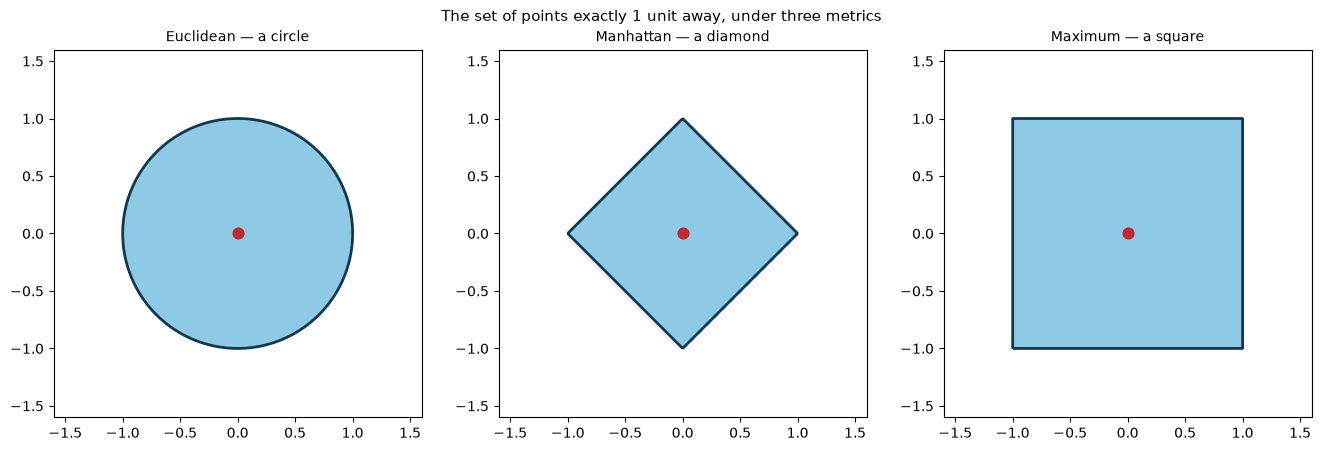

In [10]:
# What "all points within distance 1" looks like under each metric.
grid = np.linspace(-1.6, 1.6, 400)
xx, yy = np.meshgrid(grid, grid)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
shapes = [
    (np.sqrt(xx ** 2 + yy ** 2), "Euclidean — a circle"),
    (np.abs(xx) + np.abs(yy), "Manhattan — a diamond"),
    (np.maximum(np.abs(xx), np.abs(yy)), "Maximum — a square"),
]
for ax, (field, title) in zip(axes, shapes):
    ax.contourf(xx, yy, field <= 1, levels=[0.5, 1.5], colors=["#8ECAE6"])
    ax.contour(xx, yy, field, levels=[1], colors=["#12384f"], linewidths=2)
    ax.scatter([0], [0], s=60, color="#C1292E", zorder=5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
fig.suptitle("The set of points exactly 1 unit away, under three metrics", fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation:** "distance 1" is a circle, a diamond, or a square depending on the metric — three different
notions of a neighborhood, all equally valid.

**When to prefer which:**

- **Euclidean** is the default, and is what k-means assumes (the mean minimizes squared Euclidean distance).
- **Manhattan** is more robust to a single wildly different coordinate, because it does not square the
  differences — the same reason MAE resists outliers better than RMSE.
- **Maximum** is right when a single unacceptable difference disqualifies a match, regardless of the others.

⚠️ And the point that outranks all of them: **whatever metric you choose, standardize your features first.**
Chapter 6 measured a case where a distance calculation ignored age entirely because income was measured in
larger numbers. The metric cannot fix a scale problem.

### 4.2b Choosing k, and the ways k-means fails

**K is a hyperparameter** — you must supply it, and the algorithm will cheerfully return exactly k clusters
whether or not k groups exist. Two standard aids, both from Chapter 9:

- The **elbow method**: plot inertia against k and look for the bend.
- The **silhouette score**: a number to maximize, comparing each point's own cluster with the nearest other.

Both are worth running. Neither is authoritative. And beyond the choice of k, k-means has three specific
failure modes worth recognizing on sight.

**The silhouette score, defined.** For one point, work out two numbers:

- $a$ — its average distance to the **other members of its own cluster** ("how well do I fit in here?")
- $b$ — its average distance to the members of the **nearest other cluster** ("how much better could I do?")

$$s = \frac{b - a}{\max\{a,\, b\}} \qquad\qquad \text{always between } -1 \text{ and } +1$$

The score for a whole clustering is the average of $s$ over every point.

> **Worked example — three points, three verdicts.**
>
> | Point | $a$ (own cluster) | $b$ (nearest other) | $s = (b-a)/\max(a,b)$ | Verdict |
> |---|---|---|---|---|
> | A | $2$ | $6$ | $(6-2)/6 = \mathbf{+0.67}$ | Comfortably where it belongs |
> | B | $5$ | $5.5$ | $(5.5-5)/5.5 = \mathbf{+0.09}$ | Sitting on the border |
> | C | $6$ | $3$ | $(3-6)/6 = \mathbf{-0.50}$ | Closer to a *different* cluster — probably misplaced |
>
> Point A is 3× closer to its own group than to the next one. Point B could go either way. Point C is in the wrong
> cluster, and the negative sign says so. Averaging these three gives $(0.67 + 0.09 - 0.50)/3 = 0.09$ — a poor
> clustering overall, dragged down by C.

**Here is what makes the silhouette more useful than the elbow.** Inertia always improves as $k$ rises, so it can
never be maximized — you have to squint at a bend. The silhouette does not: push $k$ too high and you start
splitting real groups, which shrinks $b$ (the nearest other cluster is now a piece of your own former group) and
drives the score **down**. So you can simply try $k = 2, 3, 4, \dots$ and take the highest score. It is a number
you can genuinely optimize rather than interpret.

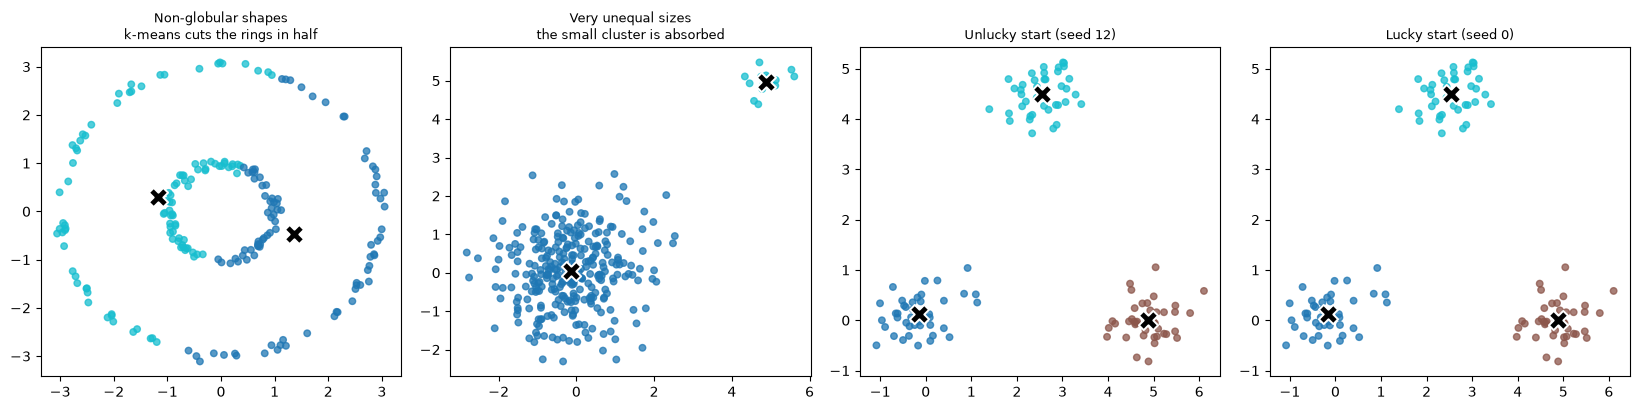

In [11]:
rng_fail = np.random.default_rng(7)

def run_kmeans(data, k, seed=0, n_iterations=60):
    generator = np.random.default_rng(seed)
    centroids = data[generator.choice(len(data), k, replace=False)]
    for _ in range(n_iterations):
        labels = np.linalg.norm(data[:, None, :] - centroids[None, :, :], axis=2).argmin(axis=1)
        updated = np.array([data[labels == c].mean(axis=0) if (labels == c).any() else centroids[c]
                            for c in range(k)])
        if np.allclose(updated, centroids):
            break
        centroids = updated
    return labels, centroids

# Failure 1 — non-globular shapes: two concentric rings.
angle = rng_fail.uniform(0, 2 * np.pi, 200)
inner_ring = np.column_stack([np.cos(angle[:100]), np.sin(angle[:100])]) * (1 + rng_fail.normal(0, 0.06, (100, 1)))
outer_ring = np.column_stack([np.cos(angle[100:]), np.sin(angle[100:])]) * (3 + rng_fail.normal(0, 0.06, (100, 1)))
rings = np.vstack([inner_ring, outer_ring])

# Failure 2 — very unequal cluster sizes.
big = rng_fail.normal(loc=(0, 0), scale=1.0, size=(300, 2))
small = rng_fail.normal(loc=(5, 5), scale=0.3, size=(15, 2))
unequal = np.vstack([big, small])

# Failure 3 — unlucky initialization on data that IS well separated.
blobs = np.vstack([rng_fail.normal(loc=c, scale=0.45, size=(40, 2))
                   for c in [(0, 0), (5, 0), (2.5, 4.5)]])

fig, axes = plt.subplots(1, 4, figsize=(16.5, 4.2))
panels = [
    (rings, 2, 0, "Non-globular shapes\nk-means cuts the rings in half"),
    (unequal, 2, 0, "Very unequal sizes\nthe small cluster is absorbed"),
    (blobs, 3, 12, "Unlucky start (seed 12)"),
    (blobs, 3, 0, "Lucky start (seed 0)"),
]
for ax, (data, k, seed, title) in zip(axes, panels):
    labels, centroids = run_kmeans(data, k, seed=seed)
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap="tab10", s=22, alpha=0.75)
    ax.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=190, c="black",
               edgecolors="white", linewidth=1.4)
    ax.set_title(title, fontsize=9.5)
plt.tight_layout()
plt.show()

**Interpretation:** three genuine limitations, each visible immediately once drawn.

1. **K-means finds spherical clusters, because it assigns points to the nearest *mean*.** The two rings are
   obvious groups to a human and impossible for k-means — it slices them down the middle. For shapes like
   this, density-based methods (DBSCAN) or spectral clustering are the right tools.
2. **It is biased toward equal-sized clusters**, because a cluster with more points pulls its centroid and
   claims more territory. The 15-point cluster is swallowed by the 300-point one.
3. **The result depends on where the centroids start.** The same data and the same k give different answers
   from different random seeds — a *local* optimum, not the best possible one. The standard fix is to run it
   several times with different starts and keep the lowest-inertia result (this is what "k-means++" and
   `n_init` do in real libraries).

**The habit to build:** always plot your clusters. Inertia and silhouette are summary numbers, and Chapter 7
already established what summary numbers hide.

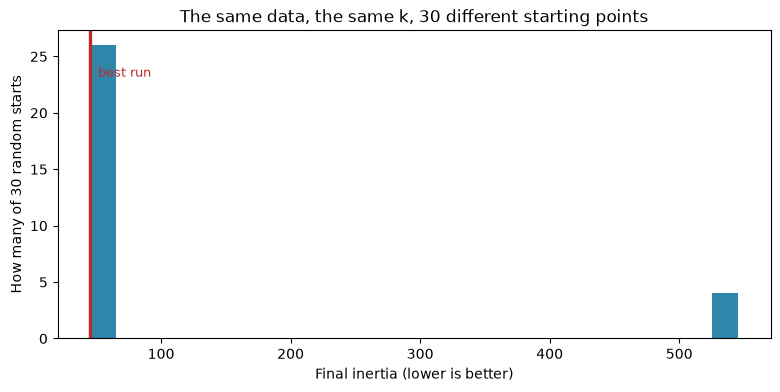

Best inertia  : 45.16
Worst inertia : 545.53  (12.1x worse)
Runs landing on the best solution: 26 of 30

This is why real implementations run k-means many times and keep the best.


In [12]:
# Failure 3, quantified: how much does the random start actually matter?
def inertia(data, labels, centroids):
    return float(sum(((data[labels == c] - centroids[c]) ** 2).sum() for c in range(len(centroids))))

results = []
for seed in range(30):
    labels, centroids = run_kmeans(blobs, 3, seed=seed)
    results.append(inertia(blobs, labels, centroids))
results = np.array(results)

fig, ax = plt.subplots(figsize=(9.2, 4)) 
ax.hist(results, bins=25, color="#2E86AB")
ax.axvline(results.min(), color="#C1292E", linewidth=2.4)
ax.text(results.min(), ax.get_ylim()[1] * 0.85, "  best run", color="#C1292E", fontsize=9)
ax.set_xlabel("Final inertia (lower is better)")
ax.set_ylabel("How many of 30 random starts")
ax.set_title("The same data, the same k, 30 different starting points")
plt.show()

print(f"Best inertia  : {results.min():.2f}")
print(f"Worst inertia : {results.max():.2f}  ({results.max()/results.min():.1f}x worse)")
print(f"Runs landing on the best solution: {(np.isclose(results, results.min())).sum()} of 30")
print("\nThis is why real implementations run k-means many times and keep the best.")

### 4.3 Hierarchical clustering — full worked example

**Problem:** a teacher wants to divide 5 students into groups based on assignment marks,
with no fixed target number of groups -- a job for hierarchical clustering, not classification.

In [13]:
students = pd.DataFrame({"student_id": [1, 2, 3, 4, 5], "marks": [10, 7, 28, 20, 35]})
students

,student_id,marks
0,1,10
1,2,7
2,3,28
3,4,20
4,5,35


**Step 1: build the proximity matrix** -- the pairwise (absolute) distance between every pair of
students' marks.

In [14]:
marks = students["marks"].values
proximity = np.abs(marks[:, None] - marks[None, :])
proximity_df = pd.DataFrame(proximity, index=students["student_id"], columns=students["student_id"])
proximity_df

student_id,1,2,3,4,5
student_id,,,,,
1,0,3,18,10,25
2,3,0,21,13,28
3,18,21,0,8,7
4,10,13,8,0,15
5,25,28,7,15,0


**Steps 2-6: repeatedly merge the two closest clusters**, updating the proximity matrix each time
(using the *maximum* mark to represent a merged cluster), until only one cluster remains.
We'll also log each merge's distance, since that's exactly what a dendrogram plots.

**🐍 Python basics — `dict(zip(...))` and building on Chapter 9's merge loop**

- `dict(zip(students["student_id"], students["marks"]))` pairs up the two columns position by position
  (`zip`, seen in Chapter 10) and feeds those pairs straight into `dict(...)`, building
  `{1: 10, 2: 7, 3: 28, ...}` in one line — an id-to-marks lookup table.
- The nested-loop "find the closest pair, then merge" logic inside `hierarchical_clustering()` is the exact
  same pattern as Chapter 9's tiny agglomerative demo — the one addition here is `cluster_marks`, a second
  dictionary tracking each cluster's *representative* mark (the maximum of whatever merged into it), which is
  what this version of the algorithm uses to decide future merges.

In [15]:
def hierarchical_clustering(student_ids, marks_dict):
    clusters = {str(sid): [sid] for sid in student_ids}
    cluster_marks = {str(sid): marks_dict[sid] for sid in student_ids}  # representative mark per cluster
    merge_log = []

    while len(clusters) > 1:
        names = list(clusters.keys())
        best_pair, best_dist = None, np.inf
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                d = abs(cluster_marks[names[i]] - cluster_marks[names[j]])
                if d < best_dist:
                    best_dist, best_pair = d, (names[i], names[j])
        a, b = best_pair
        merged_name = f"({a},{b})"
        clusters[merged_name] = clusters[a] + clusters[b]
        cluster_marks[merged_name] = max(cluster_marks[a], cluster_marks[b])  # use the max
        del clusters[a], clusters[b], cluster_marks[a], cluster_marks[b]
        merge_log.append((a, b, best_dist, merged_name))

    return merge_log

marks_dict = dict(zip(students["student_id"], students["marks"]))
merge_log = hierarchical_clustering(students["student_id"].tolist(), marks_dict)

for a, b, dist, merged in merge_log:
    print(f"Merge {a} and {b}  (distance={dist:.0f})  -> {merged}")

Merge 1 and 2  (distance=3)  -> (1,2)
Merge 3 and 5  (distance=7)  -> (3,5)
Merge 4 and (1,2)  (distance=10)  -> (4,(1,2))
Merge (3,5) and (4,(1,2))  (distance=15)  -> ((3,5),(4,(1,2)))


**Interpretation:** students 1 and 2 (marks 10, 7) merge first at distance 3 -- exactly matching the
dendrogram above, which also starts by joining students 1 and 2. Reading top to bottom, this log *is* the
sequence of merges a dendrogram draws as a tree.

**🐍 Python basics — `dict.pop()` and `enumerate(..., start=1)`**

- `groups.pop(a)` removes key `a` from the dictionary **and** returns its value in one step — handy for
  "take this cluster out and give it to me so I can merge it into something else," which is exactly what
  `groups[merged] = groups.pop(a) + groups.pop(b)` does.
- `enumerate(final_clusters, start=1)` walks through a list while also counting — normally counting starts at
  0, but `start=1` makes it count `1, 2, 3, ...` instead, which reads better for "Cluster 1," "Cluster 2,"
  and so on.

In [16]:
# Choosing the number of clusters: cut the dendrogram at a threshold distance
threshold = 12

def clusters_at_threshold(merge_log, student_ids, threshold):
    groups = {str(sid): [sid] for sid in student_ids}
    for a, b, dist, merged in merge_log:
        if dist > threshold:
            break  # stop merging once the merge distance exceeds our cut-off
        groups[merged] = groups.pop(a) + groups.pop(b)
    return list(groups.values())

final_clusters = clusters_at_threshold(merge_log, students["student_id"].tolist(), threshold)
for i, cluster in enumerate(final_clusters, start=1):
    print(f"Cluster {i}: Student ID {cluster}")
print("(Expected: Cluster 1 = [1, 2, 4], Cluster 2 = [3, 5])")

Cluster 1: Student ID [3, 5]
Cluster 2: Student ID [4, 1, 2]
(Expected: Cluster 1 = [1, 2, 4], Cluster 2 = [3, 5])


**Interpretation:** cutting the dendrogram at distance 12 stops the merging early, right after
`(1,2)` and `4` combine but *before* that group merges with `(3,5)` -- giving exactly the two
clusters. A lower threshold would give more (smaller) clusters; a higher one would give fewer (bigger) ones.

> ✏️ **Try it:** change `threshold = 12` to `threshold = 20` and re-run the cell. How many clusters do
> you get now, and does that match "cutting the tallest vertical line" as described above?

*Answer:* raising the threshold to 20 means the merge log's step 4 (distance 15, the final merge into
one root cluster) now also clears the cut — so everything collapses into a **single cluster** of all 5
students. Only step nothing is left unmerged below distance 20. This is the general trade-off: a higher
threshold means fewer, larger clusters; a lower one means more, smaller clusters. Threshold = 12 (two
clusters) and threshold = 20 (one cluster) are two different, equally "valid" answers — hierarchical
clustering does not pick one for you.

### 4.4 Linkage — the other choice hiding in hierarchical clustering

The merge loop asks "which two clusters are closest?" — but once a cluster contains several points, the
distance *between clusters* has to be defined. That definition is called the **linkage**, and the
worked example uses one specific choice (the maximum mark of the pair).

| Linkage | Distance between two clusters | Tends to produce |
|---|---|---|
| **Single** | The closest pair across them | Long, straggly chains |
| **Complete** | The farthest pair across them | Compact, roughly equal-diameter clusters |
| **Average** | The mean over all cross pairs | A compromise between the two |
| **Ward** | The increase in within-cluster variance | Compact, similarly-sized clusters (the common default) |

Different linkages on the same data give different trees.

**The same four rows, as formulas.** For two clusters $A$ and $B$:

$$d_{\text{single}}(A,B) = \min_{\mathbf{a}\in A,\, \mathbf{b}\in B} d(\mathbf{a},\mathbf{b})
\qquad\qquad
d_{\text{complete}}(A,B) = \max_{\mathbf{a}\in A,\, \mathbf{b}\in B} d(\mathbf{a},\mathbf{b})$$

$$d_{\text{average}}(A,B) = \frac{1}{\lvert A\rvert\,\lvert B\rvert} \sum_{\mathbf{a}\in A}\sum_{\mathbf{b}\in B} d(\mathbf{a},\mathbf{b})
\qquad\qquad
d_{\text{Ward}}(A,B) = \frac{\lvert A\rvert\,\lvert B\rvert}{\lvert A\rvert + \lvert B\rvert}\left\lVert \bar{\mathbf{a}} - \bar{\mathbf{b}} \right\rVert^{2}$$

The first three all look at **the same list of distances between the two clusters** and differ only in what they do
with that list — smallest, largest, or average.

> **Worked example.** Cluster $A$ holds shops at positions $1$ and $2$ along a road; cluster $B$ holds shops at
> $6$ and $10$. There are $2 \times 2 = 4$ cross-cluster distances:
>
> | Pair | Distance |
> |---|---|
> | $1 \leftrightarrow 6$ | $5$ |
> | $1 \leftrightarrow 10$ | $\mathbf{9}$ ← largest |
> | $2 \leftrightarrow 6$ | $\mathbf{4}$ ← smallest |
> | $2 \leftrightarrow 10$ | $8$ |
>
> **Single:** $\mathbf{4}$. **Complete:** $\mathbf{9}$. **Average:** $(5+9+4+8)/4 = \mathbf{6.5}$.
>
> **Ward** works differently — it asks *how much extra spread would merging create?* The two cluster centers are
> $\bar{a} = (1+2)/2 = 1.5$ and $\bar{b} = (6+10)/2 = 8$, so
> $$d_{\text{Ward}} = \frac{2 \times 2}{2 + 2} \times (1.5 - 8)^2 = 1 \times 42.25 = \mathbf{42.25}$$
>
> Four rules, four numbers: $4$, $9$, $6.5$, $42.25$. Since the algorithm always merges whichever pair of clusters
> scores lowest, a different rule can produce a different merge — and therefore a different tree.

Each has a personality. **Single** needs only one close pair, so it cheerfully strings long straggly shapes
together — and will wrongly join two real groups that happen to have one pair of neighbors touching. **Complete**
demands that *every* pair be close, so it prefers compact round clusters and tends to chop long ones in half.
**Average** compromises between them. **Ward** measures the increase in within-cluster spread, so it is minimizing
the very same $J$ that k-means minimizes — one merge at a time — and the
$\lvert A\rvert\lvert B\rvert/(\lvert A\rvert+\lvert B\rvert)$ factor makes merging two big clusters more expensive
than merging two small ones, which keeps its clusters similar in size.

The worked example takes the **maximum** of each pair, so it is using complete linkage.

In [17]:
marks_lookup = dict(zip(students["student_id"], students["marks"]))

def linkage_distance(cluster_a, cluster_b, method):
    values_a = [marks_lookup[i] for i in cluster_a]
    values_b = [marks_lookup[i] for i in cluster_b]
    pairs = [abs(a - b) for a in values_a for b in values_b]
    if method == "single":
        return min(pairs)
    if method == "complete":
        return max(pairs)
    if method == "average":
        return float(np.mean(pairs))
    raise ValueError(method)

def cluster_with(method):
    clusters = {str(sid): [sid] for sid in students["student_id"]}
    log = []
    while len(clusters) > 1:
        names = list(clusters)
        best, best_distance = None, np.inf
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                d = linkage_distance(clusters[names[i]], clusters[names[j]], method)
                if d < best_distance:
                    best_distance, best = d, (names[i], names[j])
        a, b = best
        merged = f"({a},{b})"
        clusters[merged] = clusters[a] + clusters[b]
        del clusters[a], clusters[b]
        log.append((a, b, best_distance, merged))
    return log

for method in ["single", "complete", "average"]:
    print(f"{method.upper()} linkage:")
    for a, b, distance, merged in cluster_with(method):
        print(f"   merge {a:12s} + {b:12s}  at distance {distance:5.1f}  -> {merged}")
    print()

SINGLE linkage:
   merge 1            + 2             at distance   3.0  -> (1,2)
   merge 3            + 5             at distance   7.0  -> (3,5)
   merge 4            + (3,5)         at distance   8.0  -> (4,(3,5))
   merge (1,2)        + (4,(3,5))     at distance  10.0  -> ((1,2),(4,(3,5)))

COMPLETE linkage:
   merge 1            + 2             at distance   3.0  -> (1,2)
   merge 3            + 5             at distance   7.0  -> (3,5)
   merge 4            + (1,2)         at distance  13.0  -> (4,(1,2))
   merge (3,5)        + (4,(1,2))     at distance  28.0  -> ((3,5),(4,(1,2)))

AVERAGE linkage:
   merge 1            + 2             at distance   3.0  -> (1,2)
   merge 3            + 5             at distance   7.0  -> (3,5)
   merge 4            + (1,2)         at distance  11.5  -> (4,(1,2))
   merge (3,5)        + (4,(1,2))     at distance  19.2  -> ((3,5),(4,(1,2)))



**Interpretation:** the first two merges agree — students 1 and 2 (marks 10 and 7), then students 3 and 5
(marks 28 and 35). Then the linkages **disagree about where student 4 belongs**, and the disagreement is
instructive.

Student 4 scored 20, sitting between the low group (7, 10) and the high group (28, 35).

- **Single linkage** puts student 4 with the *high* group, because it only needs one close pair and |20 − 28|
  = 8 is the smallest single gap available.
- **Complete and average linkage** put student 4 with the *low* group, because they account for the whole
  cluster: joining the high group would mean tolerating |20 − 35| = 15.

Same data, same algorithm, opposite answer for one of five students — decided entirely by a definition most
people never think about. The merge **heights** differ too (28 versus 10 for the final merge), and since the
height is where you cut, a fixed threshold gives different cluster counts under different linkages.

⚠️ **Single linkage's specific failure is called chaining.** Because it only needs *one* close pair, a thin
bridge of intermediate points will merge two otherwise distinct clusters into a long straggly chain — which is
exactly what happened to student 4 here, in miniature.

### 4.5 The dendrogram, drawn

The merge log *is* a dendrogram. Drawing it makes the "cut it wherever you like" property obvious.

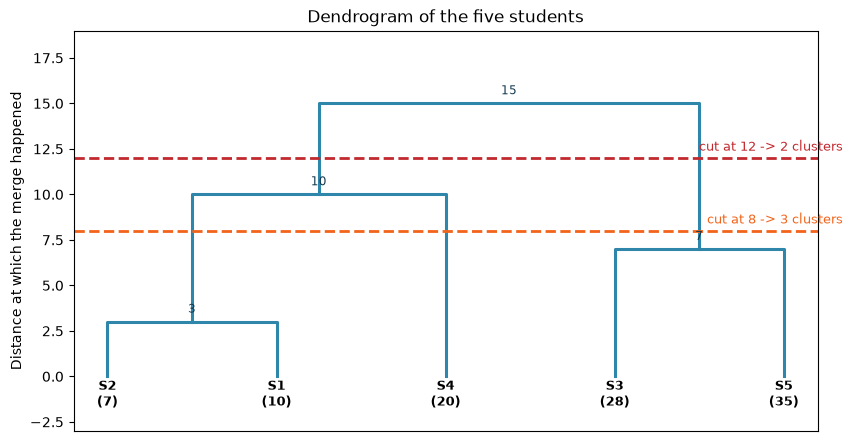

In [18]:
# Draw the merge log, so the cut thresholds line up.
merge_history = merge_log

positions, heights = {}, {}
for order, sid in enumerate([2, 1, 4, 3, 5]):        # left-to-right leaf order
    positions[str(sid)] = order
    heights[str(sid)] = 0.0

fig, ax = plt.subplots(figsize=(9.6, 5.2))
for a, b, distance, merged in merge_history:
    x_a, x_b = positions[a], positions[b]
    y_a, y_b = heights[a], heights[b]
    ax.plot([x_a, x_a, x_b, x_b], [y_a, distance, distance, y_b],
            color="#2E86AB", linewidth=2.2)
    positions[merged] = (x_a + x_b) / 2
    heights[merged] = distance
    ax.text((x_a + x_b) / 2, distance + 0.5, f"{distance:.0f}", ha="center",
            fontsize=8.5, color="#12384f")

for sid in [2, 1, 4, 3, 5]:
    ax.text(positions[str(sid)], -1.6, f"S{sid}\n({marks_lookup[sid]})",
            ha="center", fontsize=9.5, fontweight="bold")

for threshold, color, note in [(12, "#C1292E", "cut at 12 -> 2 clusters"),
                               (8, "#F26419", "cut at 8 -> 3 clusters")]:
    ax.axhline(threshold, color=color, linestyle="--", linewidth=2)
    ax.text(4.35, threshold + 0.4, note, color=color, fontsize=9, ha="right")

ax.set_ylabel("Distance at which the merge happened")
ax.set_xticks([])
ax.set_ylim(-3, max(h for h in heights.values()) + 4)
ax.set_title("Dendrogram of the five students")
plt.show()

**Interpretation:** the leaves are the five students with their marks; each horizontal bar is a merge, drawn
at the distance it happened. Read it bottom-up and it is the merge log; read it top-down and it is a
recursive splitting.

**Cutting at a height gives you clusters, and you can change your mind for free.** The red line at 12 accepts
the merges at distances 3, 7, and 10 but rejects the one at 15, leaving two clusters — {S1, S2, S4} with marks
10, 7, 20 and {S3, S5} with marks 28, 35. That is exactly the expected answer. Slide the line down to 8 and the
merge at 10 is rejected too, giving three clusters: {S1, S2}, {S4}, {S3, S5}.

One run of the algorithm supports every possible k, which is precisely the advantage over k-means, where each
k needs a fresh run.

A **large jump in merge height** is the hierarchical version of the elbow. Here the final merge at 15 is much
taller than the 10 below it, arguing for cutting between them — which is what a threshold of 12 does.

> ✏️ **Try it:** rebuild the dendrogram from `cluster_with("single")` instead and compare. Student 4 changes
> sides, and a cut at 12 no longer gives the same two clusters — a good illustration of how much the linkage
> choice matters.

## 5. Association rules

An **association rule** is a rule-based method for finding relationships between different but related
items, of the form:

$$\{\text{antecedent}\} \rightarrow \{\text{consequent}\}$$

e.g. *"If coffee is purchased, then the possibility of buying sugar is ___."* Since the 1990s, retailers have
used this ("market basket analysis") to decide product placement, bundle discounts, and promotions.

Chapter 9 introduced the three measures -- **support**, **confidence**, **lift** -- with a worked example.
Let's rebuild that same transaction table here, since association rules are this chapter's other core topic.

The three measures from Chapter 9, restated so this chapter stands on its own. For itemsets $X$ and $Y$ across $N$
transactions:

$$\text{Support}(X) = \frac{\text{transactions containing } X}{N}
\qquad
\text{Confidence}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)}
\qquad
\text{Lift}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)\,\text{Support}(Y)}$$

In everyday language: **support** is *how often does this happen at all?*, **confidence** is *when X happens, how
often does Y follow?*, and **lift** is *does knowing about X actually tell me anything new about Y?*

> **Worked example — and a rule that looks good but is worthless.** Using the 8 transactions rebuilt below, take
> the rule $\{\text{apple}\} \rightarrow \{\text{beer}\}$.
>
> Apple appears in transactions 1, 2, 3, 4 → $\text{Support}(\text{apple}) = 4/8 = 0.50$.
> Beer appears in 1, 2, 3, 5, 6, 7 → $\text{Support}(\text{beer}) = 6/8 = 0.75$.
> Both together appear in 1, 2, 3 → $\text{Support}(\text{apple, beer}) = 3/8 = 0.375$.
>
> **Confidence** $= 0.375 / 0.50 = \mathbf{0.75}$. Three out of four apple buyers also buy beer — that sounds like
> a strong rule, and a shop might act on it.
>
> **Lift** $= 0.375 / (0.50 \times 0.75) = 0.375 / 0.375 = \mathbf{1.00}$.
>
> **A lift of exactly 1 means the rule is worth nothing.** Beer is in 75% of *all* baskets anyway, so "75% of
> apple buyers also buy beer" is not a discovery about apples — it is just a fact about beer. Knowing someone
> bought an apple changes your estimate not at all.
>
> **Compare $\{\text{rice}\} \rightarrow \{\text{beer}\}$.** Rice is in 1, 2, 5, 6 → support $4/8 = 0.50$, and
> rice-with-beer is also in all four → support $0.50$.
> Confidence $= 0.50/0.50 = 1.00$, and lift $= 0.50/(0.50 \times 0.75) = \mathbf{1.33}$.
> Every rice buyer bought beer, **and** that is 33% more often than beer's baseline rate. *This* rule tells you
> something.

That is why lift is the measure to trust: $\text{Lift} = 1$ means the two items are independent, $> 1$ means they
genuinely go together, and $< 1$ means buying one makes the other *less* likely.

In [19]:
transactions = [
    {"apple", "beer", "rice"},
    {"apple", "beer", "rice"},
    {"apple", "beer"},
    {"apple", "banana"},
    {"rice", "beer", "milk"},
    {"rice", "beer"},
    {"banana", "beer", "milk"},
    {"banana", "milk"},
]

def support(itemset, transactions):
    itemset = set(itemset)
    return sum(1 for t in transactions if itemset.issubset(t)) / len(transactions)

support_apple = support({"apple"}, transactions)
support_beer = support({"beer"}, transactions)
support_apple_beer = support({"apple", "beer"}, transactions)

confidence_apple_to_beer = support_apple_beer / support_apple
lift_apple_to_beer = support_apple_beer / (support_apple * support_beer)

print(f"Support({{apple}})    = {support_apple:.0%}    -- how popular is apple alone?")
print(f"Confidence(apple->beer) = {confidence_apple_to_beer:.0%}  -- of apple-buyers, how many also buy beer?")
print(f"Lift(apple->beer)       = {lift_apple_to_beer:.2f}   -- adjusted for how popular beer already is")

Support({apple})    = 50%    -- how popular is apple alone?
Confidence(apple->beer) = 75%  -- of apple-buyers, how many also buy beer?
Lift(apple->beer)       = 1.00   -- adjusted for how popular beer already is


**Interpretation:** here, `apple` is the **antecedent** and `beer` is the **consequent**. Confidence
alone (75%) looks like a strong signal, but lift = 1.0 reveals beer is just generally popular (bought in 75%
of *all* transactions) -- so apple purchases don't actually predict beer purchases any better than chance.

> ✏️ **Try it:** compute `support({"rice", "beer"})` and `confidence(rice -> beer)`. Is rice a better or
> worse predictor of beer than apple is?

*Answer:* `support({rice, beer}) = 3/8 = 37.5%` (rice+beer appears in transactions 1, 2, and 6).
`confidence(rice -> beer) = support({rice, beer}) / support({rice}) = 0.375 / 0.5 = 75%` — the same
confidence as apple → beer. But `lift(rice -> beer) = confidence / support(beer) = 0.75 / 0.75 = 1.00`,
also exactly 1 — so rice is **no better a predictor of beer than apple was**. Both rules have identical
confidence and identical lift, because beer is popular enough (75% of all transactions) that almost anything
purchased alongside it will show high confidence without a real association.

## 6. Summary

- Unsupervised learning has four main tasks: **clustering**, **association rule mining**,
  **dimensionality reduction**, and **anomaly detection**.
- **Dimensionality reduction** drops redundant, highly-correlated features while keeping the important
  information; **anomaly detection** flags points that don't fit any normal cluster (isolated, far from
  their nearest neighbors).
- **K-means** (hard clustering) iteratively assigns points to the nearest centroid and recomputes centroids
  until stable. **Hierarchical clustering** (soft clustering) builds a tree of merges from a proximity
  matrix, visualized as a **dendrogram** -- cutting it at a chosen distance threshold determines the number
  of clusters.
- **Association rules** ({antecedent} -> {consequent}) are measured by **support**, **confidence**, and
  **lift** -- with lift being what protects you from mistaking "popular" for "predictive."


### 6.1 Glossary

Every term introduced in this chapter, in one place.

| Term | Meaning |
|---|---|
| **Anomaly / outlier** | A point that deviates from the standard behavior of the rest of the data — flagged here by having no close neighbors. |
| **Antecedent** | The "if" side of an association rule, `{X}` in `{X} → {Y}`. |
| **Association rule** | A pattern of the form `{X} → {Y}`: "baskets containing X tend to contain Y too." |
| **Centroid** | The center of a cluster: the mean position of all points currently assigned to it. |
| **Cluster** | A group of examples that resemble one another, discovered rather than given. |
| **Confidence** | For rule `{X} → {Y}`: Support(X ∪ Y) ÷ Support(X) — how often Y appears when X does. |
| **Consequent** | The "then" side of an association rule, `{Y}` in `{X} → {Y}`. |
| **Dendrogram** | The tree diagram produced by hierarchical clustering; join heights are merge distances. |
| **Dimensionality reduction** | Reducing the number of features in a dataset while keeping most of the important information. |
| **Euclidean distance** | Straight-line distance between two points — the everyday sense of "distance." |
| **Hard clustering** | Each point belongs to exactly one cluster, completely (e.g. K-means). |
| **Hierarchical clustering** | Builds a full tree of clusters by repeatedly merging the two closest ones; you cut the tree later to choose the final grouping. |
| **K-means** | A hard-clustering algorithm: choose `k`, pick starting centroids, assign points to the nearest one, recompute, repeat until stable. |
| **Lift** | Confidence(X → Y) ÷ Support(Y) — corrects confidence for how popular Y already is. Lift = 1 means no real association; > 1 means positive association. |
| **Manhattan distance** | Sum of absolute differences along each axis — "city-block" distance. |
| **Market basket analysis** | Association rule mining applied to retail transactions, used since the 1990s for product placement and promotions. |
| **Proximity matrix** | A table of the pairwise distance between every pair of points, used to drive hierarchical clustering's merges. |
| **Soft clustering** | A point can have a degree of membership across multiple clusters, rather than one hard assignment. |
| **Support** | Support(X) = (transactions containing X) ÷ (all transactions) — how common an itemset is. |
| **Threshold (dendrogram cut)** | The distance value at which merging stops; every branch the horizontal cut line crosses becomes one final cluster. |



### 5.1 Generating every rule, not just one

One rule is an example. A market basket analysis produces *all* rules above chosen thresholds, ranked so
someone can act on the top few.

In [20]:
from itertools import combinations, chain

items = sorted({item for transaction in transactions for item in transaction})
print(f"{len(items)} distinct items across {len(transactions)} transactions: {items}\n")

def all_rules(transactions, min_support=0.20, min_confidence=0.50):
    rules = []
    # Every itemset of size 2 or more, split every possible way into if -> then.
    for size in range(2, len(items) + 1):
        for itemset in combinations(items, size):
            itemset = set(itemset)
            itemset_support = support(itemset, transactions)
            if itemset_support < min_support:
                continue
            for r in range(1, len(itemset)):
                for antecedent in combinations(sorted(itemset), r):
                    antecedent = set(antecedent)
                    consequent = itemset - antecedent
                    confidence = itemset_support / support(antecedent, transactions)
                    if confidence < min_confidence:
                        continue
                    lift = confidence / support(consequent, transactions)
                    rules.append({
                        "rule": f"{{{', '.join(sorted(antecedent))}}} -> {{{', '.join(sorted(consequent))}}}",
                        "support": round(itemset_support, 3),
                        "confidence": round(confidence, 3),
                        "lift": round(lift, 2),
                    })
    return pd.DataFrame(rules).sort_values("lift", ascending=False).reset_index(drop=True)

rules = all_rules(transactions)
print(f"{len(rules)} rules pass support >= 20% and confidence >= 50%.\n")
rules.head(12)

5 distinct items across 8 transactions: ['apple', 'banana', 'beer', 'milk', 'rice']

14 rules pass support >= 20% and confidence >= 50%.



,rule,support,confidence,lift
0,{banana} -> {milk},0.250,0.667,1.78
1,{milk} -> {banana},0.250,0.667,1.78
2,"{rice} -> {apple, beer}",0.250,0.500,1.33
3,"{apple, beer} -> {rice}",0.250,0.667,1.33
4,{rice} -> {beer},0.500,1.000,1.33
5,{beer} -> {rice},0.500,0.667,1.33
6,"{apple, rice} -> {beer}",0.250,1.000,1.33
7,{rice} -> {apple},0.250,0.500,1.00
8,{apple} -> {beer},0.375,0.750,1.00
9,{beer} -> {apple},0.375,0.500,1.00


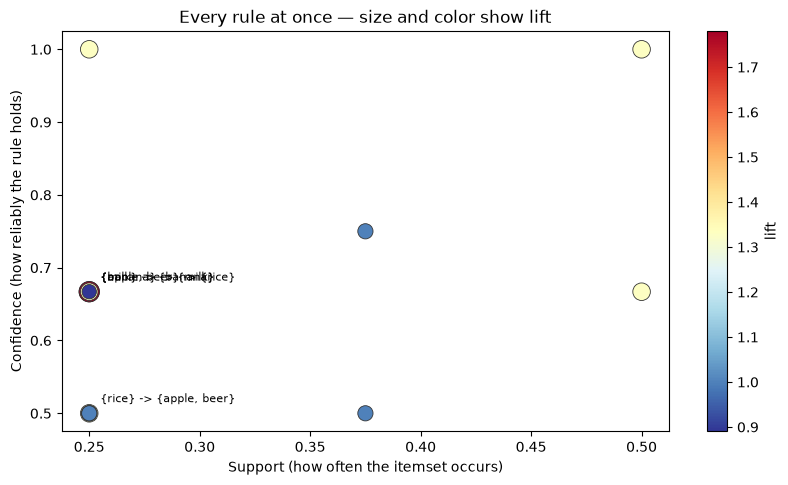

Rules worth acting on sit UP and to the RIGHT, and are colored red (high lift).

Rules with lift <= 1.0 (no real association): 7 of 14


In [21]:
fig, ax = plt.subplots(figsize=(9.8, 5.2))
scatter = ax.scatter(rules["support"], rules["confidence"], s=rules["lift"] * 120,
                     c=rules["lift"], cmap="RdYlBu_r", edgecolors="#333", linewidth=0.6)
for _, row in rules.nlargest(4, "lift").iterrows():
    ax.annotate(row["rule"], (row["support"], row["confidence"]),
                textcoords="offset points", xytext=(8, 8), fontsize=8)
ax.set_xlabel("Support (how often the itemset occurs)")
ax.set_ylabel("Confidence (how reliably the rule holds)")
ax.set_title("Every rule at once — size and color show lift")
fig.colorbar(scatter, ax=ax, label="lift")
plt.show()

print("Rules worth acting on sit UP and to the RIGHT, and are colored red (high lift).")
print(f"\nRules with lift <= 1.0 (no real association): "
      f"{(rules['lift'] <= 1.0).sum()} of {len(rules)}")

**Interpretation:** the chart is the standard way to triage a rule set. **Support** on the x-axis is how often
the rule applies at all; **confidence** on the y-axis is how reliable it is; **lift** is the color and size.

A rule needs all three to be worth acting on:

- High confidence and low support: real but affects almost nobody — a shelf change for three customers.
- High support and lift ≈ 1: common coincidence, exactly the apple → beer case from Chapter 9.
- High on all three: act on it.

Note how many rules have lift at or below 1. **Confidence alone would have promoted several of them**, which
is the warning both this chapter and Chapter 9 keep making.

### 5.2 The combinatorial wall Apriori was built to climb

The cell above enumerated every possible itemset. With 5 items that is trivial. With a real supermarket's
catalog it is impossible.

**How big the problem gets.** A catalog of $n$ different items can be combined into

$$2^{n} - 1$$

possible itemsets, and checking them all means testing each one against every transaction.

> **Worked example — the numbers, growing.**
>
> | Items in the catalog | Itemsets to check | |
> |---|---|---|
> | $5$ | $2^5 - 1 = \mathbf{31}$ | instant |
> | $10$ | $2^{10} - 1 = \mathbf{1{,}023}$ | still instant |
> | $20$ | $2^{20} - 1 \approx \mathbf{1\ million}$ | noticeable |
> | $30$ | $2^{30} - 1 \approx \mathbf{1\ billion}$ | a serious wait |
> | $1{,}000$ | $2^{1000}$ — a number with over **300 digits** | impossible, forever |
>
> Every single item added to the catalog **doubles** the work. A supermarket carries thousands. No faster computer
> touches a problem that grows like this — the enumeration has to be *avoided*, not sped up.

**The observation that makes avoiding it possible.** Adding an item to a set can never make it more common:

$$\text{if } X \subseteq Y \text{ then } \text{Support}(Y) \leq \text{Support}(X)$$

This is obvious once said aloud: every basket holding $\{$bread, milk, eggs$\}$ necessarily also holds
$\{$bread, milk$\}$, so the bigger set cannot appear in more baskets. Turned around, it becomes a pruning rule:

> **Worked example — one check that eliminates thousands.** Suppose caviar appears in $1\%$ of baskets, and our
> minimum support is $5\%$. Caviar is rare, so **every** itemset containing caviar — $\{$caviar, bread$\}$,
> $\{$caviar, milk$\}$, $\{$caviar, bread, milk$\}$, and so on — must appear in at most $1\%$ of baskets too, and
> therefore fails as well.
>
> With 1,000 other items in the catalog, that single observation discards **all $2^{999}$ itemsets containing
> caviar without counting a single one of them.**

Apriori turns this into a method: find the frequent single items, build candidate pairs **only** from those
survivors, keep the frequent pairs, build triples only from those, and so on. Each round reads the data once, and
each round's candidates are assembled exclusively from the previous round's winners — which in practice throws away
the overwhelming majority of that $2^n$ before it is ever written down.

In [22]:
print(f"{'Distinct items':>16} {'Possible itemsets':>26}")
for n_items in [5, 10, 20, 50, 100, 1_000]:
    total = 2 ** n_items - n_items - 1        # all subsets, minus singletons and the empty set
    print(f"{n_items:>16,} {total:>26,.0f}" if n_items <= 50
          else f"{n_items:>16,} {'about 10^' + str(int(n_items * np.log10(2))):>26}")

print("\nA supermarket carries tens of thousands of products.")
print("Enumerating every itemset is not slow — it is impossible, at any scale of hardware.")

  Distinct items          Possible itemsets
               5                         26
              10                      1,013
              20                  1,048,555
              50      1,125,899,906,842,573
             100                about 10^30
           1,000               about 10^301

A supermarket carries tens of thousands of products.
Enumerating every itemset is not slow — it is impossible, at any scale of hardware.


**Interpretation:** the count doubles with every additional product. At 100 items there are more itemsets than
atoms in a small planet, and no amount of computing power changes that.

**The Apriori principle** makes the problem tractable with one observation:

> If an itemset is infrequent, then **every** superset of it is also infrequent.

If {caviar} appears in only 0.1% of baskets, then {caviar, bread} cannot appear in more than 0.1% — adding an
item can only ever make a set *rarer*. So once {caviar} fails the support threshold, every set containing
caviar can be discarded without being examined.

In [23]:
# Apriori in action: build up itemset sizes, pruning as you go.
def apriori_frequent_itemsets(transactions, min_support=0.20):
    frequent = {frozenset([item]) for item in items
                if support({item}, transactions) >= min_support}
    all_frequent = list(frequent)
    size = 1
    checked, pruned = len(items), 0

    while frequent:
        size += 1
        # Only combine itemsets that are already known to be frequent.
        candidates = {a | b for a in frequent for b in frequent if len(a | b) == size}
        # Apriori pruning: drop any candidate with an infrequent subset.
        survivors = set()
        for candidate in candidates:
            if all(frozenset(subset) in set(all_frequent)
                   for subset in combinations(candidate, size - 1)):
                survivors.add(candidate)
            else:
                pruned += 1
        checked += len(survivors)
        frequent = {c for c in survivors if support(set(c), transactions) >= min_support}
        all_frequent.extend(frequent)
    return all_frequent, checked, pruned

frequent_itemsets, checked, pruned = apriori_frequent_itemsets(transactions)
brute_force = 2 ** len(items) - 1

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
for itemset in sorted(frequent_itemsets, key=lambda s: (len(s), sorted(s))):
    print(f"   {{{', '.join(sorted(itemset))}}}  support = {support(set(itemset), transactions):.0%}")

print(f"\nItemsets Apriori had to score : {checked}")
print(f"Itemsets brute force would score: {brute_force}")
print(f"Candidates pruned without scoring: {pruned}")

Frequent itemsets found: 11
   {apple}  support = 50%
   {banana}  support = 38%
   {beer}  support = 75%
   {milk}  support = 38%
   {rice}  support = 50%
   {apple, beer}  support = 38%
   {apple, rice}  support = 25%
   {banana, milk}  support = 25%
   {beer, milk}  support = 25%
   {beer, rice}  support = 50%
   {apple, beer, rice}  support = 25%

Itemsets Apriori had to score : 16
Itemsets brute force would score: 31
Candidates pruned without scoring: 3


**Interpretation:** on five items the saving is modest. The point is that the saving **compounds**: pruning at
size 2 removes candidates at sizes 3, 4, 5 and beyond that never get generated at all. On a real catalog this
is the difference between an analysis that finishes overnight and one that never finishes.

Apriori is a good example of a broadly useful idea: **when the search space is too large, find a property that
lets you eliminate whole regions without examining them.**

---
## 6.2 Check your understanding

**Q1.** You run k-means with k = 4 and get four clean-looking clusters. Does the data have four groups?

<details><summary>Answer</summary>

Not necessarily — k-means returns exactly the k you ask for, always. Check the elbow and silhouette, plot the
result, and then ask a domain expert whether the groups correspond to anything real. Only the last step can
actually answer the question.
</details>

**Q2.** Your two clusters are concentric rings. Why does k-means fail, and what would you use?

<details><summary>Answer</summary>

K-means assigns each point to the nearest *mean*, which produces roughly spherical clusters — and the two
rings share a center, so their means nearly coincide. It slices the rings in half instead. Use a density-based
method such as DBSCAN, or spectral clustering.
</details>

**Q3.** Running k-means twice on the same data gives different answers. Is it broken?

<details><summary>Answer</summary>

No. It converges to a *local* optimum that depends on the random starting centroids — the simulation showed 30
seeds producing noticeably different inertias. Run it many times and keep the lowest-inertia result; real
libraries do this by default.
</details>

**Q4.** What is the practical advantage of hierarchical clustering over k-means?

<details><summary>Answer</summary>

One run supports every k. The dendrogram can be cut at any height, and the merge heights themselves tell you
how similar the merged groups were, so a large jump indicates a natural place to stop. K-means needs a
separate run per k and tells you nothing about confidence.
</details>

**Q5.** Two analysts use different linkage methods and disagree about how many clusters there are. Who is
right?

<details><summary>Answer</summary>

Both, in the sense that linkage is a modeling choice rather than a fact. Complete linkage reports larger merge
distances than single linkage, so the same cut threshold yields different cluster counts. State which linkage
you used — an unreported linkage makes a dendrogram unreproducible.
</details>

**Q6.** Why must you standardize before clustering or PCA?

<details><summary>Answer</summary>

Both are driven by scale. Distance is dominated by whichever feature has the largest numeric range, and PCA
maximizes variance, which is also largest for the biggest-unit column. Without standardizing, "income in baht"
would decide the answer and "age in years" would be ignored.
</details>

**Q7.** PCA says two components explain 97% of the variance. Can you tell your manager which original features
matter?

<details><summary>Answer</summary>

Only indirectly. Components are weighted combinations of *all* the original features, not a selection from
them. Inspect the loadings to see which features dominate each component and name them accordingly — but that
naming is interpretation, and if the manager needs actual features, PCA was the wrong tool.
</details>

**Q8.** A point is flagged as an anomaly. Should you delete it?

<details><summary>Answer</summary>

No — identify, explain, then decide (Chapter 6). The flag says the point is unusual, not wrong. It might be a
sensor fault, a data-entry error, a fraud, or your most valuable customer, and only domain knowledge can tell
which.
</details>

**Q9.** Your kNN anomaly detector flags normal points in a sparse cluster while missing an outlier next to a
dense one. What is wrong?

<details><summary>Answer</summary>

It uses one global distance threshold, and the clusters have different densities. A normal point in a sparse
region legitimately has distant neighbors. Use a *local* density method, which compares each point's
neighborhood with its own neighbors' neighborhoods rather than with a fixed number.
</details>

**Q10.** A rule has 80% confidence. Is it worth acting on?

<details><summary>Answer</summary>

Check lift and support first. If the consequent appears in 80% of all baskets anyway, lift is 1 and the rule
carries no information — the apple → beer case from Chapter 9 exactly. And a high-lift rule with tiny support is a
real pattern affecting almost nobody.
</details>

**Q11.** Why does Apriori not simply check every possible itemset?

<details><summary>Answer</summary>

Because the number of itemsets doubles with each additional product, so a real catalog makes exhaustive
enumeration impossible at any scale of hardware. Apriori uses the fact that a superset of an infrequent
itemset must also be infrequent, which lets it discard entire families of candidates without ever scoring
them.
</details>

## 7. Homework 📝

### 👤 Student information

**Name:**  *(double-click to edit this cell and fill in your name)*

**Student ID:**

**Date:**

### The homework dataset — 📦 Warehouse SKU picks

Run the cell below to generate data for 6 warehouse items (SKUs): how many times each was picked (pulled
from a shelf) last week, plus a small set of order "baskets" for the association-rule exercise. **Do not
modify it** — everyone's numbers must match.

In [24]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)

skus = pd.DataFrame({
    "sku_id": [1, 2, 3, 4, 5, 6],
    "picks_last_week": [12, 15, 47, 50, 9, 90],
})

item_pool = ["gloves", "tape", "boxes", "labels", "bubble_wrap"]
orders = []
for _ in range(10):
    n_items = hw_rng.integers(1, 4)
    orders.append(set(str(item) for item in hw_rng.choice(item_pool, size=n_items, replace=False)))

print(skus)
print()
for i, order in enumerate(orders, start=1):
    print(f"Order {i}: {order}")

   sku_id  picks_last_week
0       1               12
1       2               15
2       3               47
3       4               50
4       5                9
5       6               90

Order 1: {'boxes', 'bubble_wrap', 'tape'}
Order 2: {'boxes'}
Order 3: {'labels', 'bubble_wrap', 'tape'}
Order 4: {'boxes', 'bubble_wrap'}
Order 5: {'gloves', 'labels', 'bubble_wrap'}
Order 6: {'boxes'}
Order 7: {'bubble_wrap'}
Order 8: {'tape'}
Order 9: {'labels', 'boxes'}
Order 10: {'boxes'}


---

### Exercise 1 — Proximity matrix

Using the Section 4.3 pattern, build the 6x6 proximity matrix (absolute difference in `picks_last_week`) for
the `skus` DataFrame.

In [25]:
# YOUR CODE HERE (Exercise 1)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---

### Exercise 2 — Hierarchical clustering

Using the Section 4.3 `hierarchical_clustering()` function, run agglomerative clustering on `skus` (by
`picks_last_week`). Print the merge log. Which two SKUs merge first, and why does that make sense given their
pick counts?

In [26]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---

### Exercise 3 — Cut the dendrogram

Using your merge log from Exercise 2 and the `clusters_at_threshold()` function, find a threshold that splits
the 6 SKUs into exactly **3** groups. Report your threshold and the resulting clusters. (There may be more
than one valid threshold — any one that works is fine.)

In [27]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---

### Exercise 4 — K-means

Using the Section 4.2 K-means pattern, cluster the `skus` into `k=2` groups based on `picks_last_week` alone
(reshape it into a 2-D array of shape `(6, 1)` first, e.g. `skus[["picks_last_week"]].values`). Which SKUs
end up in the "high-pick" cluster?

In [28]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---

### Exercise 5 — Association rules

Using the `orders` list and the Section 5 `support()` function, compute `Support({"tape"})`,
`Confidence(tape -> boxes)`, and `Lift(tape -> boxes)`. Is there a positive, negative, or no association
between picking tape and picking boxes together?

In [29]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---

### Exercise 6 — Anomaly detection

SKU 6 was picked 90 times last week, far more than any other SKU. Using the Section 3 nearest-neighbor
distance idea (but simplified to 1-D: nearest neighbor = the SKU with the closest `picks_last_week`), would
SKU 6 get flagged as an anomaly if the threshold were "nearest neighbor distance > 20"? Show your work.

In [30]:
# YOUR CODE HERE (Exercise 6)


**✍️ Your answer to Question 6:**

---

### Bonus — Dimensionality reduction reasoning

Suppose the warehouse also tracks `picks_last_week` and `picks_last_month` for each SKU, and the two are
almost perfectly correlated (a SKU picked often in a week is also picked often in a month, roughly
proportionally). Using the Section 2 idea, explain in 1-2 sentences whether it would be safe to drop one of
these two columns before clustering, and why.

In [31]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---

### ✅ Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file